<a href="https://colab.research.google.com/github/pranacollab/prana-sentinel/blob/main/notebooks/prana_sentinel_poc_03_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prana Sentinel — PoC Phase 3
## Dengue Prediction Model — Rio de Janeiro
### Inputs: Dengue Cases, Land Surface Temperature, NDVI
### Date: March 2026

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

Mounted at /content/drive


In [ ]:
df_dengue = pd.read_csv('/content/drive/MyDrive/prana_sentinel_poc_01_dengue_rio.csv')
df_lst = pd.read_csv('/content/drive/MyDrive/prana_sentinel_poc_02_lst_rio.csv')
df_ndvi = pd.read_csv('/content/drive/MyDrive/prana_sentinel_poc_02_ndvi_rio.csv')

# Convert dates
df_dengue['data_iniSE'] = pd.to_datetime(df_dengue['data_iniSE'])
df_lst['date'] = pd.to_datetime(df_lst['date'])
df_ndvi['date'] = pd.to_datetime(df_ndvi['date'])

print("Dengue shape:", df_dengue.shape)
print("LST shape:", df_lst.shape)
print("NDVI shape:", df_ndvi.shape)

Dengue shape: (104, 31)
LST shape: (90, 3)
NDVI shape: (46, 3)


In [ ]:
# Rename date columns to match
df_dengue = df_dengue.rename(columns={'data_iniSE': 'date'})

# Keep only what we need from dengue
df_dengue = df_dengue[['date', 'casos']]

# Keep only what we need from LST and NDVI
df_lst = df_lst[['date', 'LST_celsius']]
df_ndvi = df_ndvi[['date', 'NDVI']]

# Merge using nearest date match since datasets have different frequencies
df_lst = df_lst.sort_values('date')
df_ndvi = df_ndvi.sort_values('date')
df_dengue = df_dengue.sort_values('date')

# Merge LST onto dengue by nearest date
df = pd.merge_asof(df_dengue, df_lst, on='date', direction='nearest')

# Merge NDVI onto combined dataset by nearest date
df = pd.merge_asof(df, df_ndvi, on='date', direction='nearest')

print(df.shape)
print(df.head(10))
print(df.isnull().sum())

(104, 4)
        date  casos  LST_celsius      NDVI
0 2022-01-02     21    28.904630  0.339963
1 2022-01-09     14    28.904630  0.339963
2 2022-01-16     22    32.068078  0.663396
3 2022-01-23     19    32.813535  0.663396
4 2022-01-30     31    32.785347  0.680194
5 2022-02-06     35    32.785347  0.680194
6 2022-02-13     47    29.989889  0.676978
7 2022-02-20     62    28.338646  0.676978
8 2022-02-27     66    32.233759  0.664501
9 2022-03-06    116    32.609955  0.664501
date           0
casos          0
LST_celsius    0
NDVI           0
dtype: int64


In [ ]:
# Add lagged features — environmental conditions from prior weeks
df['LST_lag1'] = df['LST_celsius'].shift(1)  # 1 week ago
df['LST_lag2'] = df['LST_celsius'].shift(2)  # 2 weeks ago
df['LST_lag3'] = df['LST_celsius'].shift(3)  # 3 weeks ago

df['NDVI_lag1'] = df['NDVI'].shift(1)
df['NDVI_lag2'] = df['NDVI'].shift(2)
df['NDVI_lag3'] = df['NDVI'].shift(3)

# Add cases from prior weeks as a feature too
df['casos_lag1'] = df['casos'].shift(1)
df['casos_lag2'] = df['casos'].shift(2)

# Drop rows with nulls created by the lag shift
df = df.dropna()

print(df.shape)
print(df.head(5))

(101, 12)
        date  casos  LST_celsius      NDVI   LST_lag1   LST_lag2   LST_lag3  \
3 2022-01-23     19    32.813535  0.663396  32.068078  28.904630  28.904630   
4 2022-01-30     31    32.785347  0.680194  32.813535  32.068078  28.904630   
5 2022-02-06     35    32.785347  0.680194  32.785347  32.813535  32.068078   
6 2022-02-13     47    29.989889  0.676978  32.785347  32.785347  32.813535   
7 2022-02-20     62    28.338646  0.676978  29.989889  32.785347  32.785347   

   NDVI_lag1  NDVI_lag2  NDVI_lag3  casos_lag1  casos_lag2  
3   0.663396   0.339963   0.339963        22.0        14.0  
4   0.663396   0.663396   0.339963        19.0        22.0  
5   0.680194   0.663396   0.663396        31.0        19.0  
6   0.680194   0.680194   0.663396        35.0        31.0  
7   0.676978   0.680194   0.680194        47.0        35.0  


In [ ]:
# Define features and target
features = [
    'LST_celsius', 'LST_lag1', 'LST_lag2', 'LST_lag3',
    'NDVI', 'NDVI_lag1', 'NDVI_lag2', 'NDVI_lag3',
    'casos_lag1', 'casos_lag2'
]

X = df[features]
y = df['casos']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False preserves time order
)

# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.1f} cases")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: 103.0 cases
R² Score: 0.773


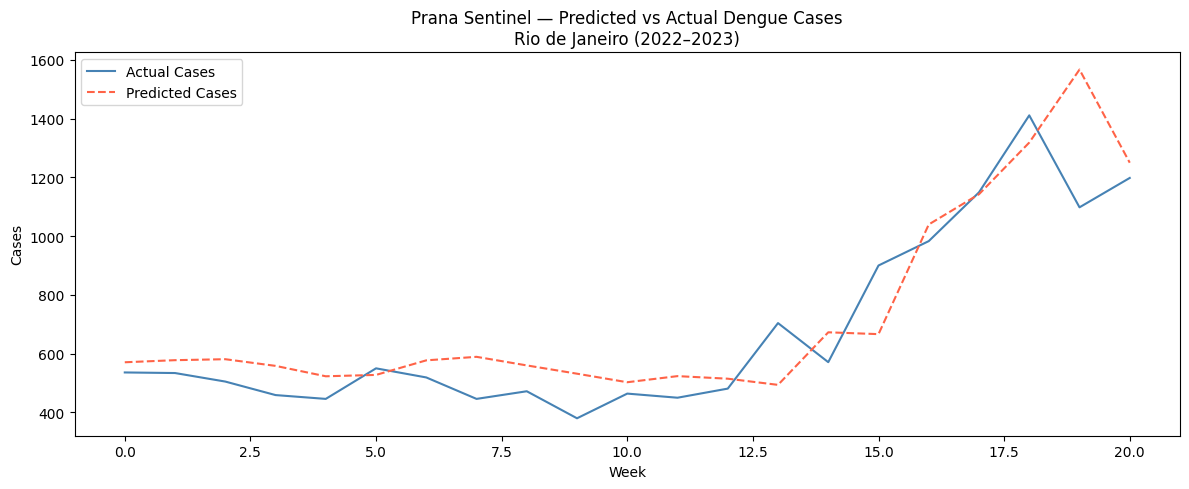

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Cases', color='steelblue')
plt.plot(y_pred, label='Predicted Cases', color='tomato', linestyle='--')
plt.title('Prana Sentinel — Predicted vs Actual Dengue Cases\nRio de Janeiro (2022–2023)')
plt.xlabel('Week')
plt.ylabel('Cases')
plt.legend()
plt.tight_layout()
plt.show()

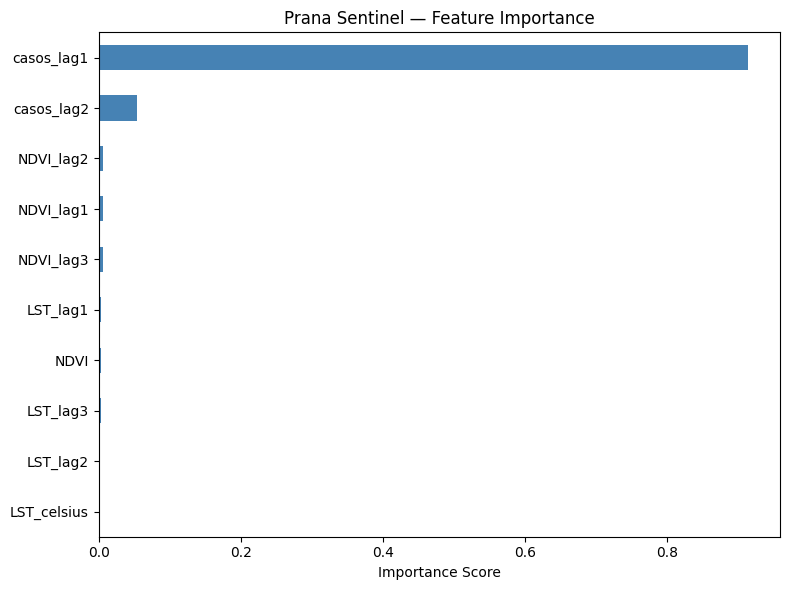

In [ ]:
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Prana Sentinel — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save the trained model
joblib.dump(model, '/content/drive/MyDrive/prana_sentinel_poc_03_model.pkl')
print("Model saved successfully!")

# Save the merged dataset
df.to_csv('/content/drive/MyDrive/prana_sentinel_poc_03_merged_data.csv', index=False)
print("Merged dataset saved successfully!")

Model saved successfully!
Merged dataset saved successfully!


import joblib

# Save the trained model
joblib.dump(model, '/content/drive/MyDrive/prana_sentinel_poc_03_model.pkl')
print("Model saved successfully!")

# Save the merged dataset
df.to_csv('/content/drive/MyDrive/prana_sentinel_poc_03_merged_data.csv', index=False)
print("Merged dataset saved successfully!")
```

---

## Notebook 03 — Summary

In this notebook we built the first working predictive model for Prana
Sentinel, Ananta Holding Group's Space-Enabled Health Intelligence System
(SEHIS) targeting dengue outbreak forecasting in Brazil.

We merged three datasets — weekly dengue case counts, MODIS Land Surface
Temperature, and MODIS NDVI vegetation index — into a single aligned
dataframe covering Rio de Janeiro from 2022–2023. Lag features were
engineered to capture the delayed relationship between environmental
conditions and outbreak timing, reflecting the biological reality of
mosquito breeding cycles.

A Random Forest regression model was trained on the combined dataset,
achieving an R² score of 0.773 and a Mean Absolute Error of 103 cases
per week — a strong baseline result for a two-variable, two-year dataset.

Feature importance analysis revealed that prior case counts are currently
the dominant predictive signal, with satellite variables (LST and NDVI)
contributing minimally at this stage. This finding shapes the next phase
of development, which will prioritize adding precipitation data, extending
the historical training window to 5–10 years, and testing longer lag
windows of 4–6 weeks to better capture the environmental drivers of
outbreak risk.

The trained model has been saved to Google Drive for future iteration.
This notebook represents a complete proof of concept pipeline: from raw
satellite and epidemiological data ingestion through feature engineering
to a working predictive model — the technical foundation of Prana
Sentinel as a viable SEHIS.